# Den 2 · Naučíme síť rozumět pohybu

Blok 1: síť dostane **surový signál z telefonu** a sama se naučí pohyby
rozeznávat — nikdo jí neřekne, čeho si všímat.
Blok 2: podíváme se jí **do hlavy**, ČEHO si všimla — a naučíme ji nový
pohyb úplně bez přetrénování.

*Buňky jen spouštíme (`Shift+Enter`); odvození děláme na tabuli.*

## Nasbíraná data
Telefon má v sobě dvě čidla: **akcelerometr** (měří zrychlení — jak se s ním
cuká) a **gyroskop** (měří otáčení). Obě měří zhruba 50× za sekundu
a pokaždé zapíšou tři čísla: x, y, z.

Každá vaše nahrávka ≈ 20 sekund jednoho pohybu a nesou se s ní dvě nálepky:
**jaký pohyb** to byl a **kdo** ho nahrál. Nic víc síť nedostane.

Vaše nahrávky si notebook **stáhne rovnou ze sběrného serveru** — jedním
requestem na adresu `/data` (můžete si ji otevřít i v prohlížeči).

In [ ]:
import json                                      # data ze serveru chodí jako JSON
import time                                      # měření, jak dlouho co trvá
import urllib.request                            # stahování z internetu
import numpy as np                               # počítání s tabulkami čísel
import matplotlib.pyplot as plt                  # kreslení grafů
from IPython.display import clear_output         # umí přemazat obrázek → animace
import os; os.environ.update(TF_CPP_MIN_LOG_LEVEL="2", TF_ENABLE_ONEDNN_OPTS="0")   # jen ticho pro bonus na konci

plt.rcParams.update({"font.size": 13, "axes.titlesize": 15, "axes.titleweight": "bold",
                     "axes.grid": True, "grid.alpha": 0.25, "legend.frameon": False,
                     "figure.autolayout": True})   # větší písmo a čistý vzhled na projektor
BARVY = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]   # barvy pohybů (a nového navíc)

TRIDY = ["klid", "chůze", "skoky"]               # základní pohyby dne

In [ ]:
ADRESA = "https://ls.in4you.cz"          # náš sběrný server

def nacti_nahravky():
    """Stáhne všechny nahrávky ze serveru (seřazené od nejstarší po nejnovější).

    Každá nahrávka je slovník: osoba, pohyb a tři sloupce čísel —
    t (sekundy), zrychleni (x, y, z) a otaceni (x, y, z)."""
    nahravky = json.load(urllib.request.urlopen(ADRESA + "/data", timeout=15))   # jeden request
    for n in nahravky:                           # čísla z internetu → numpy pole
        n["t"] = np.array(n["t"], dtype=float)
        n["zrychleni"] = np.array(n["zrychleni"], dtype=float)
        n["otaceni"] = np.array(n["otaceni"], dtype=float)
    return nahravky

nahravky = nacti_nahravky()
print("Staženo:", len(nahravky), "nahrávek od",
      len({n["osoba"] for n in nahravky}), "lidí")
for pohyb in TRIDY:                              # rychlá kontrola: máme od všeho dost?
    pocet = sum(1 for n in nahravky if n["pohyb"] == pohyb)
    print(f"   {pohyb}: {pocet}×")

## Co telefon vlastně naměřil
První graf: **surové čtení akcelerometru** — tři křivky pro osy $x, y, z$.
Všimněte si: i když telefon **leží v klidu**, jedna osa ukazuje ±9,8 m/s².
To není pohyb, to je **gravitace** — akcelerometr ji od pohybu nepozná.
(A výrobci se nedomluvili na znaménku: iPhone hlásí −9,8, Android +9,8.)

In [ ]:
klid = [n for n in nahravky if n["pohyb"] == "klid"][0]   # jedna nahrávka klidu

plt.figure(figsize=(10, 3.5))
for sloupec, osa in enumerate("xyz"):            # tři křivky: osy x, y, z
    plt.plot(klid["t"], klid["zrychleni"][:, sloupec], lw=1, label=osa)
plt.axhline(9.81, color="gray", ls="--"); plt.axhline(-9.81, color="gray", ls="--")
plt.title("klid: jedna osa „leží“ na gravitaci")
plt.xlabel("čas (s)"); plt.xlim(0, 8); plt.legend(); plt.show()

Tři osy jsou nešikovné — stačí telefon v kapse pootočit a všechny tři
křivky vypadají úplně jinak. Uděláme proto z každé trojice jedno číslo:
**délku šipky zrychlení** $|\vec{a}| = \sqrt{a_x^2+a_y^2+a_z^2}$. Délka
šipky se otočením telefonu nezmění (je jedno, jak ho kdo drží) a v klidu
sedí na „podlaze" 9,8 — tu se naučíme smazat za chvíli.

A proč pohyby netřídit ručně psanými pravidly (`když špička > 10, jsou to
skoky`)? Podívejte se, jak různě vypadá **tentýž** pohyb od různých lidí.
Přesně o tuhle pestrost se ručně psaná pravidla rozbijí — necháme stroj,
ať si pravidla **najde sám z dat**.

In [ ]:
def velikost(vektory):
    """Délka šipky (x, y, z) v každém čase — Pythagoras ve 3D."""
    return np.sqrt(np.nansum(vektory ** 2, axis=1))

plt.figure(figsize=(13, 3))
for k, pohyb in enumerate(TRIDY):
    ukazky = [n for n in nahravky if n["pohyb"] == pohyb]
    plt.subplot(1, 3, k + 1)                     # jeden panel na pohyb
    for n in ukazky[:4]:                         # až 4 nahrávky přes sebe — každá jiná!
        plt.plot(n["t"], velikost(n["zrychleni"]), color=BARVY[k], alpha=0.5, lw=1)
    plt.axhline(9.81, color="gray", ls="--")     # „podlaha" = gravitace
    plt.title(pohyb, color=BARVY[k]); plt.xlabel("čas (s)"); plt.xlim(0, 8)
plt.show()

## Krájení na okénka
Síť neumí spolknout celou 20sekundovou nahrávku najednou — potřebuje
**stejně velká sousta**. Nahrávku proto nakrájíme na okénka dlouhá
**2 s** a s dalším okénkem se posuneme jen o
**0,5 s** — okénka se tedy **překrývají**.

Jak takové krájení vypadá na malém příkladu: data `[1, 2, 3, 4, 5, 6, 7, 8]`,
okénko = 4 čísla, krok = 2 čísla:

    data:     [1, 2, 3, 4, 5, 6, 7, 8]
    okénko 1: [1, 2, 3, 4]
    okénko 2:       [3, 4, 5, 6]
    okénko 3:             [5, 6, 7, 8]

Proč to děláme?
- Z jedné nahrávky máme rázem **desítky příkladů** na učení místo jednoho.
- Síť se naučí pohyb poznávat, **ať začal kdykoli** — nějaké okénko ho
  vždycky chytne celý.

Drobnost pod pokličkou: každý telefon měří jinak rychle, tak každé okénko
ještě přerýsujeme na přesně **64 puntíků** — a tím jsou si
okénka ze všech telefonů rovná.

In [ ]:
data = np.array([1, 2, 3, 4, 5, 6, 7, 8])        # miniaturní „nahrávka" z příkladu nahoře

for zacatek in range(0, len(data) - 4 + 1, 2):   # okénko = 4 čísla, posun o 2
    print("okénko od pozice", zacatek, ":", data[zacatek:zacatek + 4])

A teď doopravdy — stejná myšlenka, jen okénka měříme v sekundách a každé
hned přerýsujeme na 64 puntíků:

In [ ]:
DELKA_OKNA = 2.0   # délka okénka v sekundách (pár kroků chůze / několik skoků)
KROK_OKNA = 0.5    # posun mezi okénky — překrývají se
OREZ = 0.7         # ustřihnout okraje nahrávky (mačkání tlačítek)
BODU = 64          # každé okénko přerýsujeme na tolik puntíků

def nakrajej_na_okenka(t, hodnoty):
    """Nakrájí jeden signál na překrývající se okénka — jako nahoře s [1..8]."""
    okenka, zacatky = [], []
    zacatek = t[0] + OREZ
    while zacatek + DELKA_OKNA <= t[-1] - OREZ:
        puntiky = np.linspace(zacatek, zacatek + DELKA_OKNA, BODU)   # 64 časů uvnitř okénka
        okenka.append(np.interp(puntiky, t, hodnoty))   # přečti signál v těch časech
        zacatky.append(zacatek)
        zacatek = zacatek + KROK_OKNA                   # posuň se o krok
    # reshape: i když je nahrávka moc krátká na jediné okénko, vrať tabulku
    # se správným počtem sloupců (jinak by se prázdný výsledek nedal slepit)
    return np.array(okenka).reshape(-1, BODU), np.array(zacatky)

In [ ]:
ukazky_skoku = [n for n in nahravky if n["pohyb"] == "skoky"]
vzorek = ukazky_skoku[0]                         # jedna nahrávka skoků na ukázku
sila = velikost(vzorek["zrychleni"])
okenka, zacatky = nakrajej_na_okenka(vzorek["t"], sila)   # nakrájet!

plt.figure(figsize=(11, 3))
plt.plot(vzorek["t"], sila, color="black", lw=1)
for i, zacatek in enumerate(zacatky[:12]):       # prvních 12 okének jako barevné pásy
    plt.axvspan(zacatek, zacatek + DELKA_OKNA, alpha=0.10, color=BARVY[i % 2])
plt.xlim(0, zacatky[11] + DELKA_OKNA + 0.3)
plt.title("skoky: okénka se posouvají a překrývají — každé chytí pár skoků")
plt.xlabel("čas (s)"); plt.show()
print("Z jedné nahrávky:", len(okenka), "okének po", BODU, "číslech")

## Blok 1 · Síť dostane rovnou signál (okénko → 8 → počet pohybů)
Žádné ruční předžvýkání — na vstup dáme čísla rovnou tak, jak je telefon
naměřil, a necháme síť, ať si **sama najde, čeho si všímat**.
Okénko zrychlení má 64 čísel a k němu **přilepíme stejné okénko otáčení** z gyroskopu — síť tedy dostane 128 čísel najednou. (V kódu je to seznam `CIDLA` — můžete přepnout na samotné zrychlení či otáčení a porovnat.)

Co dělá jeden neuron? Vezme všech 128 čísel, každé vynásobí svojí
**vahou**, všechno sečte a přičte posun — jedno „vážené hodnocení" okénka.
A aby síť uměla víc než přímky, výsledek se ještě „zmáčkne" funkcí tanh
do (−1, 1).
Zapsáno jako na tabuli: $h = \tanh(W_1 x + b_1)$ — skrytá vrstva je 8
takových neuronů najednou.

In [ ]:
CIDLA = ["zrychleni", "otaceni"]   # co síť dostane — zkuste i ["zrychleni"] nebo ["otaceni"]

def okenka_nahravky(nahravka):
    """Okénka jedné nahrávky: z každého čidla v CIDLA 64 čísel, slepené vedle sebe."""
    kusy = []
    for cidlo in CIDLA:
        okenka_cidla, zacatky = nakrajej_na_okenka(nahravka["t"], velikost(nahravka[cidlo]))
        kusy.append(okenka_cidla)
    return np.hstack(kusy), zacatky              # hstack = slepit vedle sebe

def priprav_okenka(nahravky, tridy):
    """Všechny nahrávky vybraných pohybů → X (okénka) a y (správné odpovědi)."""
    X, y = [], []
    for n in nahravky:
        if n["pohyb"] not in tridy:
            continue
        okenka, _ = okenka_nahravky(n)
        X.append(okenka)
        y = y + [tridy.index(n["pohyb"])] * len(okenka)   # správná odpověď ke každému okénku
    return np.vstack(X), np.array(y)

X, y = priprav_okenka(nahravky, TRIDY)
nahravky_rano = nahravky                         # snímek pro Blok 2 (nahrávek pak ještě přibude)
STRED, MERITKO = X.mean(axis=0), X.std(axis=0) + 1e-9   # standardizace (pojistka: nedělit nulou)
X = (X - STRED) / MERITKO                        # průměr 0, měřítko 1 — TADY zmizela podlaha 9,81
print("okének na učení:", len(X), "· čísel na okénko:", X.shape[1])

### Ze skóre pravděpodobnosti: softmax
Poslední vrstva dá každému pohybu **skóre** a **softmax**
$p_k = e^{z_k} / \sum_j e^{z_j}$ udělá ze skóre pravděpodobnosti (kladná
čísla, dohromady 1). Příklad: skóre $(2,\ 0,\ -1)$ → $(0{,}84,\ 0{,}11,\ 0{,}04)$
— síť neříká „chůze!", říká „na 84 % chůze".

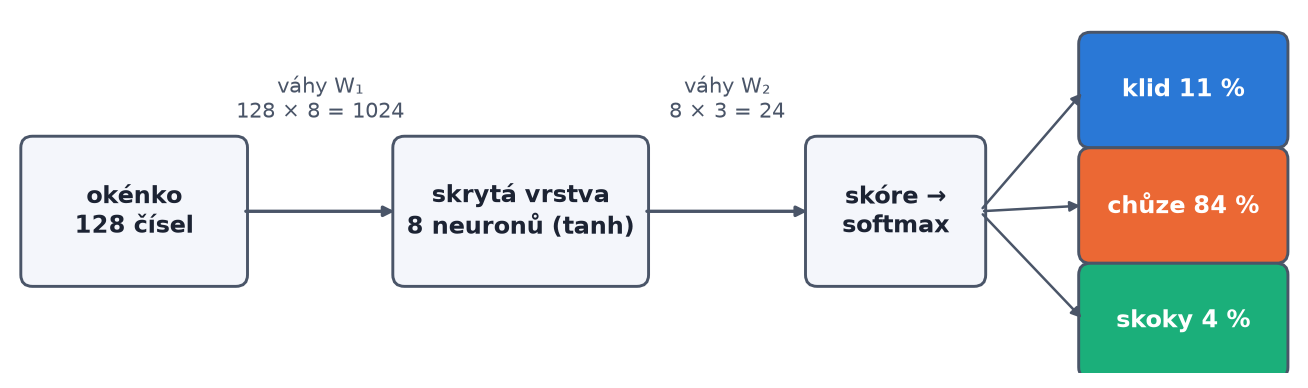

**Jak číst kód pod tím:**
- `X @ W1` — zavináč je v Pythonu **násobení matic** (řádek krát sloupec,
  přesně to $W x$ z tabule). Jedním zápisem se spočítají všechna okénka naráz.
- `dopredu` = síť odpovídá; `krok_uceni` = síť se kousek opraví
  (vzorce uvnitř jsou derivace z tabule).

In [ ]:
class MalaSit:
    """Malá síť:  okénko signálu → 8 skrytých neuronů (tanh) → pravděpodobnosti pohybů."""

    def __init__(self, vstupu, skrytych, trid, seminko=0):
        rnd = np.random.default_rng(seminko)               # na startu jen malá náhodná čísla
        self.W1 = rnd.normal(0, 1 / np.sqrt(vstupu), (vstupu, skrytych))
        self.b1 = np.zeros(skrytych)                       # W = váhy, b = posuny
        self.W2 = rnd.normal(0, 1 / np.sqrt(skrytych), (skrytych, trid))
        self.b2 = np.zeros(trid)

    def dopredu(self, X):
        """Odpověď sítě: okénka proženeme vrstvami → pravděpodobnost každého pohybu."""
        self.skryta = np.tanh(X @ self.W1 + self.b1)      # „@“ = násobení matic (Wx z tabule); tanh mačká do (-1, 1)
        z = self.skryta @ self.W2 + self.b2               # skóre pro každou přihrádku (pohyb)
        ez = np.exp(z - z.max(axis=1, keepdims=True))     # e^skóre („− max“ jen ať čísla nepřetečou)
        return ez / ez.sum(axis=1, keepdims=True)          # softmax: kladná čísla se součtem 1

    def krok_uceni(self, X, Y, rychlost=0.3):
        """Jeden krok učení: kde se síť spletla, tam se váhy posunou kousek k lepšímu."""
        P = self.dopredu(X)
        chyba_vystupu = (P - Y) / len(X)                   # co síť řekla MINUS co říct měla
        do_skryte = chyba_vystupu @ self.W2.T * (1 - self.skryta ** 2)   # táž chyba poslaná o vrstvu níž
        self.W2 -= rychlost * self.skryta.T @ chyba_vystupu    # posuny vah = derivace z tabule
        self.b2 -= rychlost * chyba_vystupu.sum(axis=0)
        self.W1 -= rychlost * X.T @ do_skryte
        self.b1 -= rychlost * do_skryte.sum(axis=0)
        return -np.mean(np.log(P[Y > 0] + 1e-9))           # ztráta: pokuta za špatnou jistotu


sit = MalaSit(vstupu=X.shape[1], skrytych=8, trid=len(TRIDY))   # zatím neumí nic — váhy jsou náhodné

## Trénink — sledujte, jak klesá ztráta
Síť potřebuje vědět, jak vypadá správná odpověď. Použijeme **one-hot**:
každý pohyb má svou „přihrádku" a správná odpověď znamená všechno do té
jedné přihrádky — klid → $[1, 0, 0]$, chůze → $[0, 1, 0]$, skoky → $[0, 0, 1]$.

**Ztráta (loss)** je pokuta za špatnou jistotu — čím míň síť věří správné
odpovědi, tím větší pokuta:

| síť dává správné odpovědi… | pokuta |
|---|---|
| 100 % | 0 |
| 33 % (tip ze tří možností) | 1,1 |
| 1 % („to určitě ne!") | 4,6 |

Takže až křivka spadne z 1,1 (samé tipování) k nule, síť to umí — správně
a jistě. (Přesný vzorec pokuty máme na tabuli.)

**Krok učení** posune každou váhu o kousíček tím směrem, kterým pokuta
klesá — a tohle zopakujeme 3000×.

Čeho si síť v signálu všímá, si právě vymýšlí **sama** — my teď vidíme jen,
JAK dobře jí to jde. Do hlavy se jí podíváme v Bloku 2.

In [ ]:
Y = np.eye(len(TRIDY))[y]                       # one-hot: klid→[1,0,0], chůze→[0,1,0], skoky→[0,0,1]
prubeh = []                                      # sem si zapisujeme ztrátu → křivka učení
for krok in range(3001):
    prubeh.append(sit.krok_uceni(X, Y))          # jeden krok učení na VŠECH okénkách najednou
    if krok % 100 == 0:                          # každých 100 kroků překreslíme graf
        trefeno = (sit.dopredu(X).argmax(axis=1) == y).mean()   # podíl správně určených okének
        clear_output(wait=True)
        plt.figure(figsize=(9, 4.5))
        plt.plot(prubeh, color=BARVY[0], lw=2)
        plt.xlim(0, 3000); plt.ylim(bottom=0)
        plt.xlabel("krok učení"); plt.ylabel("ztráta (pokuta)")
        plt.title(f"krok {krok}/3000 · pokuta {prubeh[-1]:.3f} · trefeno {trefeno:.0%}")
        plt.show()

## Živá klasifikace 🙋
Dobrovolník nahraje ~10 s pohybu na telefonu → spustíme buňku. Nahrávka se
nakrájí na okénka a síť rozhodne **každé okénko zvlášť** — barevný pruh
ukazuje, co si síť myslela v průběhu času; celkový verdikt vypíšeme pod graf.

Pak soutěž **oklamej síť**! Síť vidí jen velikost zrychlení a otáčení
ve dvousekundových okénkách — nevidí, kdo telefon drží, ani jak se u toho
tváří. Najděte pohyb, který ji splete: kdo ji oklame, přišel na to,
*čeho si síť všímá*.

In [ ]:
zivy = nacti_nahravky()[-1]                      # poslední odeslaná nahrávka — dobrovolníkova

okenka, zacatky = okenka_nahravky(zivy)          # stejné krájení jako u tréninku…
assert len(okenka) > 0, "Nahrávka je moc krátká (pod ~4 s) — nahraj novou, delší!"
okenka = (okenka - STRED) / MERITKO              # …i stejná standardizace

P = sit.dopredu(okenka)                          # verdikt sítě pro KAŽDÉ okénko zvlášť
verdikty = P.argmax(axis=1)

plt.figure(figsize=(11, 3.5))
plt.plot(zivy["t"], velikost(zivy["zrychleni"]), color="black", lw=1)
for zacatek, v in zip(zacatky, verdikty):        # pruh = co si síť myslela v tu chvíli
    plt.axvspan(zacatek, zacatek + KROK_OKNA, color=BARVY[v], alpha=0.3, lw=0)
plt.title(f"nahrává: {zivy['osoba']} — barva pruhu = verdikt okénka")
plt.xlabel("čas (s)"); plt.show()

podil = np.bincount(verdikty, minlength=len(TRIDY)) / len(verdikty)   # sečti hlasy okének
print(f"Síť říká: {TRIDY[podil.argmax()]} ({podil.max():.0%} okének)")

# Blok 2 · Nový pohyb
Vymyslete nový pohyb — jinou **kombinaci** síly, tempa a zubatosti, než mají
ty základní! — a několik z vás ho nahraje (~15 s každý).

Jenže: naše síť má **jednu přihrádku na každý naučený pohyb** (proto ten
one-hot). Přihrádky se rozdaly na začátku tréninku a novou nejde jen tak
přilepit — poslední vrstva by najednou měla špatný počet výstupů.

In [ ]:
nahravky = nacti_nahravky()                      # stáhnout znovu — přibylo něco?
vsechny_pohyby = sorted({n["pohyb"] for n in nahravky})   # názvy všech pohybů v datech
NOVE = [pohyb for pohyb in vsechny_pohyby if pohyb not in TRIDY]
print("Nové pohyby:", ", ".join(NOVE) if NOVE else "žádné — nejdřív nahrajte!")
if len(NOVE) > 1:                                # dva názvy pro jeden pohyb = asi překlep!
    print("POZOR: použije se jen první — zkontrolujte, jestli je to jeden pohyb, ne překlep.")

## Pokus č. 1: postaru — přestavět a přetrénovat všechno
Poznáváte? **Přesně tenhle trénink jsme dělali ráno.** A teď ho kvůli jedné
nové přihrádce musíme spustit celý znovu: nová síť od nuly, všechna data
znovu. Sledujte, jak dlouho to trvá — a to máme stovky okének,
ne miliardy textů.

In [ ]:
novy_pohyb = NOVE[0]                             # (spadne, dokud nový pohyb nedorazí)
TRIDY4 = TRIDY + [novy_pohyb]                    # staré přihrádky + nová

X4, y4 = priprav_okenka(nahravky, TRIDY4)        # okénka VŠECH pohybů, úplně znovu
X4 = (X4 - X4.mean(axis=0)) / (X4.std(axis=0) + 1e-9)
Y4 = np.eye(len(TRIDY4))[y4]
print("okének:", len(X4), "· přihrádek:", len(TRIDY4))

sit4 = MalaSit(vstupu=X4.shape[1], skrytych=8, trid=len(TRIDY4))   # nová síť od nuly!
zacatek_mereni = time.time()                     # stopneme si, jak dlouho to trvá
for krok in range(4001):                         # …a celý trénink od nuly, se všemi daty
    ztrata = sit4.krok_uceni(X4, Y4)
    if krok % 500 == 0:
        trefeno = (sit4.dopredu(X4).argmax(axis=1) == y4).mean()
        print(f"krok {krok:>4}: pokuta {ztrata:.2f}, trefeno {trefeno:.0%}")
print(f"Celé přetrénování: {time.time() - zacatek_mereni:.0f} s —"
      f" a to máme stovky okének, ne miliardy textů.")
print("Funguje… ale tohle by nás čekalo u KAŽDÉHO dalšího pohybu. Musí to jít líp.")

## Pokus č. 2: síť s úzkým hrdlem (okénko → 8 → **2** → pohyby)
Doprostřed sítě vložíme **hrdlo**: vrstvu jen o dvou neuronech. Funguje jako
úzké hrdlo láhve — všechno, co síť o pohybu ví, se musí protáhnout **dvěma
čísly** $(h_1, h_2)$.

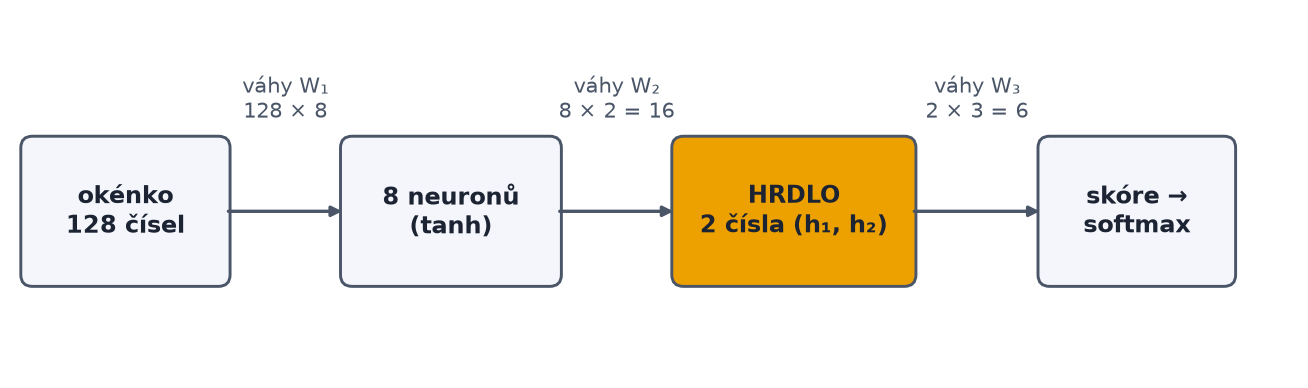

A dvě čísla, to jsou **souřadnice**: každé okénko dostane bod v rovině,
každý pohyb svůj mrak bodů. Síť si tak musí sama vymyslet dvě veličiny,
které pohyby nejlíp odliší — vlastní „příznaky", podle svého.

Detail v kódu: za správnou odpověď tentokrát nechceme jistotu 100 %, ale
jen ~87 %. Stoprocentně jistá síť by totiž body natlačila do rohů čtverce
a z mapy by zbyly tři slepené hromádky.

In [ ]:
class SitSHrdlem:
    """Síť s úzkým hrdlem:  okénko → 8 neuronů → HRDLO 2 neurony → pohyby.

    Jako úzké hrdlo láhve: všechno, co síť o pohybu ví, se musí protáhnout
    dvěma čísly — a dvě čísla si umíme nakreslit jako bod v rovině."""

    def __init__(self, vstupu, skrytych, trid, seminko=0):
        rnd = np.random.default_rng(seminko)
        self.W1 = rnd.normal(0, 1 / np.sqrt(vstupu), (vstupu, skrytych))
        self.b1 = np.zeros(skrytych)
        self.W2 = rnd.normal(0, 1 / np.sqrt(skrytych), (skrytych, 2))
        self.b2 = np.zeros(2)
        self.W3 = rnd.normal(0, 1 / np.sqrt(2), (2, trid))
        self.b3 = np.zeros(trid)

    def dopredu(self, X):
        """Jako u malé sítě — jen mezi vrstvami je navíc hrdlo ze 2 neuronů."""
        self.skryta = np.tanh(X @ self.W1 + self.b1)            # stejný začátek jako ráno
        self.hrdlo = np.tanh(self.skryta @ self.W2 + self.b2)   # ← 2 čísla = „adresa" pohybu v rovině
        z = self.hrdlo @ self.W3 + self.b3                      # rozhodnutí už jen z těch 2 čísel!
        ez = np.exp(z - z.max(axis=1, keepdims=True))
        return ez / ez.sum(axis=1, keepdims=True)               # softmax → pravděpodobnosti

    def krok_uceni(self, X, Y, rychlost=0.3):
        """Stejné učení jako u malé sítě, jen chyba prochází o vrstvu víc."""
        P = self.dopredu(X)
        chyba = (P - Y) / len(X)
        do_hrdla = chyba @ self.W3.T * (1 - self.hrdlo ** 2)    # chybu pošli zpátky vrstvu po vrstvě
        do_skryte = do_hrdla @ self.W2.T * (1 - self.skryta ** 2)
        self.W3 -= rychlost * self.hrdlo.T @ chyba
        self.b3 -= rychlost * chyba.sum(axis=0)
        self.W2 -= rychlost * self.skryta.T @ do_hrdla
        self.b2 -= rychlost * do_hrdla.sum(axis=0)
        self.W1 -= rychlost * X.T @ do_skryte
        self.b1 -= rychlost * do_skryte.sum(axis=0)
        self.W2 *= 0.999; self.b2 *= 0.999      # jemná brzda: mraky nesmí přilnout ke stěnám čtverce
        return -np.mean(np.log(P[Y > 0] + 1e-9))


# učit se bude zase JEN na základních pohybech — ranní X a y můžeme rovnou recyklovat
Yz = np.eye(len(TRIDY))[y] * 0.8 + 0.2 / len(TRIDY)   # cíl ~87 % místo 100 %: mraky nesmí zkolabovat

Učení startuje z náhodných vah, takže každý start vymyslí trochu **jinou
mapu** — jako když pět lidí kreslí mapu téže krajiny. Pět sítí potichu
natrénujeme (pořád **jen na základních pohybech**!) a pak vybereme tu,
ve které se okénka nového pohybu drží nejdál od starých mraků.

Pozor, fér hra: síť se novým pohybem **neučí ani jeden krok** — jen si mezi
pěti hotovými sítěmi vybíráme tu nejšikovnější.

In [ ]:
UKAZEK = 6                                       # okénka nového pohybu „na ukázku" (~3 s)
Xn, _ = priprav_okenka(nahravky, [novy_pohyb])   # okénka nového pohybu…
Xn = (Xn - STRED) / MERITKO                      # …stejná kuchyně jako ráno

print("Trénuju 5 sítí po sobě — chvilku to pomele…")
vysledky = []
for seminko in range(5):                         # 5 startů z různých náhodných vah
    pokus = SitSHrdlem(vstupu=X.shape[1], skrytych=8, trid=len(TRIDY), seminko=seminko)
    for _ in range(4000):                        # potichu natrénovat (jen základní pohyby!)
        pokus.krok_uceni(X, Yz)

    pokus.dopredu(X)                             # kam padla stará okénka?
    stredy = np.array([pokus.hrdlo[y == k].mean(axis=0) for k in range(len(TRIDY))])
    pokus.dopredu(Xn)                            # a kam padá nový pohyb? (BEZ učení!)
    novy_stred = pokus.hrdlo[:UKAZEK].mean(axis=0)
    body = pokus.hrdlo[UKAZEK:]                  # zbylá okénka nového pohybu
    k_novemu = np.sqrt(((body - novy_stred) ** 2).sum(axis=1))    # vzdálenost k novému středu
    ke_starym = np.min([np.sqrt(((body - s) ** 2).sum(axis=1)) for s in stredy], axis=0)
    odstup = (ke_starym - k_novemu).mean()       # kladný = nový mrak má vlastní místo
    print(f"start {seminko}: odstup nového pohybu {odstup:+.2f}")
    vysledky.append((odstup, seminko))

nej_odstup, SEMINKO = max(vysledky)              # vyhrává největší odstup
print(f"→ vítězí start {SEMINKO}")

## Trénink vítěze — mraky se rozestupují
Každý bod = jedno okénko prohnané sítí; jeho souřadnice = ta dvě čísla
z hrdla. Na startu je uprostřed chaos. Učením se mraky rozestupují — dobře
oddělené mraky se poslední vrstvě snadno třídí, tak je učení od sebe
roztahuje. Dívejte se: síť si právě **vynalézá vlastní příznaky**.

In [ ]:
def nakresli_mraky(body, y, tridy):
    """Každý bod = jedno okénko; barva = pohyb; osy = 2 čísla z hrdla."""
    for k, pohyb in enumerate(tridy):
        moje = body[y == k]
        plt.scatter(moje[:, 0], moje[:, 1], s=12, alpha=0.6, color=BARVY[k], label=pohyb)
    plt.xlim(-1.15, 1.15); plt.ylim(-1.15, 1.15)   # tanh drží všechno v (-1, 1)
    plt.xlabel("hrdlo 1"); plt.ylabel("hrdlo 2")

hrdlo_sit = SitSHrdlem(vstupu=X.shape[1], skrytych=8, trid=len(TRIDY), seminko=SEMINKO)
for krok in range(4001):
    hrdlo_sit.krok_uceni(X, Yz)                  # učí se rozhodovat…
    if krok % 200 == 0:                          # …a my kreslíme, co má zrovna v hrdle
        clear_output(wait=True)
        plt.figure(figsize=(7, 6.5))
        nakresli_mraky(hrdlo_sit.hrdlo, y, TRIDY)
        plt.title(f"Rovina, kterou si síť vymyslela SAMA · krok {krok}")
        plt.legend(); plt.show()

## Kdo vymyslel osy? Člověk vs. síť
Vlevo: dvě čísla, která by z okénka spočítal **člověk** — razance (jak
silně to hází) a kostrbatost (jak zubatá je křivka) — síť je **nikdy
neviděla**, je to jen naše srovnání.
Vpravo: rovina hrdla — osy si **vymyslela síť sama**, jen z toho,
že potřebovala třídit pohyby.

Téhle adrese v rovině se říká **embedding**. Přesně takhle „vidí" dnešní
velké modely slova, obrázky i zvuk: body v prostoru, kde *podobné = blízko*.

In [ ]:
# ruční příznaky spočítáme z okének zrychlení (bez standardizace, ať mají jednotky)
vsechna_a = []
for n in nahravky_rano:                          # RANNÍ snímek — stejné pořadí, sedí k y
    if n["pohyb"] in TRIDY:
        okenka_a, _ = nakrajej_na_okenka(n["t"], velikost(n["zrychleni"]))
        vsechna_a.append(okenka_a)
vsechna_a = np.vstack(vsechna_a)

razance = vsechna_a.std(axis=1)                                       # jak silně to hází
kostrbatost = np.abs(np.diff(vsechna_a, axis=1)).mean(axis=1) / razance   # jak zubatě

plt.figure(figsize=(13, 6))
plt.subplot(1, 2, 1)                             # vlevo: osy vymyslel člověk
for k, pohyb in enumerate(TRIDY):
    plt.scatter(razance[y == k], kostrbatost[y == k], s=12, alpha=0.6,
                color=BARVY[k], label=pohyb)
plt.xlabel("razance (síla pohybu)"); plt.ylabel("kostrbatost (zubatost)")
plt.title("Kdyby osy vymyslel ČLOVĚK"); plt.legend()

plt.subplot(1, 2, 2)                             # vpravo: osy si vybrala síť
hrdlo_sit.dopredu(X)
nakresli_mraky(hrdlo_sit.hrdlo, y, TRIDY)
plt.title("Osy si vybrala SÍŤ"); plt.legend()
plt.show()

## Nový pohyb BEZ přetrénování (few-shot)
A teď to hlavní. Okénka nového pohybu hotovou sítí jen **proženeme** —
neučíme, jen se ptáme — a v rovině přibude nový mrak. Z prvních ~3 sekund
(6 okének) spočítáme jeho **střed**. Nový klasifikátor je pak jediná
otázka: „ke kterému středu máš nejblíž?"

Ani jeden krok učení — a síť pozná pohyb, který při tréninku nikdy
neviděla. Přesně na tomhle principu stojí dnešní AI: model se draze
**předtrénuje jednou** a nové úlohy se pak řeší hrstkou ukázek.

In [ ]:
hrdlo_sit.dopredu(X);  adresy_stare = hrdlo_sit.hrdlo.copy()   # adresy starých okének v rovině
hrdlo_sit.dopredu(Xn); adresy_nove = hrdlo_sit.hrdlo.copy()    # adresy nového pohybu — BEZ učení!

stredy = np.array([adresy_stare[y == k].mean(axis=0) for k in range(len(TRIDY))])
novy_stred = adresy_nove[:UKAZEK].mean(axis=0)   # střed nového mraku z pouhých ~3 sekund
vsechny_stredy = np.vstack([stredy, novy_stred])

# test na ZBYLÝCH okénkách nového pohybu: ke kterému středu mají nejblíž?
test = adresy_nove[UKAZEK:]
vzdalenosti = np.array([np.sqrt(((test - s) ** 2).sum(axis=1)) for s in vsechny_stredy])
uspesnost = (vzdalenosti.argmin(axis=0) == len(TRIDY)).mean()   # trefily nový střed?

plt.figure(figsize=(8, 6.8))
nakresli_mraky(adresy_stare, y, TRIDY)
plt.scatter(adresy_nove[:, 0], adresy_nove[:, 1], s=14, color=BARVY[3], label=novy_pohyb)
plt.scatter(adresy_nove[:UKAZEK, 0], adresy_nove[:UKAZEK, 1], s=150, facecolors="none",
            edgecolors="black", linewidths=2, label=f"{UKAZEK} okének pro střed")
plt.scatter(vsechny_stredy[:, 0], vsechny_stredy[:, 1], marker="X", s=170,
            color="black", label="středy mraků")
plt.title(f"Nový pohyb „{novy_pohyb}“ · bez tréninku · úspěšnost {uspesnost:.0%}")
plt.legend(); plt.show()
print(f"Žádné přetrénování: ~3 sekundy pohybu stačí na {uspesnost:.0%}.")

## Uložení vah
Celá natrénovaná síť = pár tabulek čísel. Uložíme je do souboru — a kdokoli
si je načte a síť používá bez tréninku. Přesně tohle jsou ta „stažitelná AI"
z internetu: soubory s váhami.

In [ ]:
np.savez("../backup/vahy_hrdlo_dnes.npz",       # celá síť = těchhle šest tabulek čísel…
         W1=hrdlo_sit.W1, b1=hrdlo_sit.b1,
         W2=hrdlo_sit.W2, b2=hrdlo_sit.b2,
         W3=hrdlo_sit.W3, b3=hrdlo_sit.b3,
         stred=STRED, meritko=MERITKO,           # …plus recept na standardizaci
         tridy=TRIDY)
print("Uloženo: backup/vahy_hrdlo_dnes.npz")
# (Kdyby živý trénink selhal: otevři notebooks/zaloha.ipynb — jede z předtrénovaných vah.)

## Bonus · Stejná síť v profi knihovně (TensorFlow)
Ruční verzi jsme dnes psali, abychom **viděli dovnitř**. V praxi tohle za
vás udělá knihovna: vrstvy jen vyjmenujete a derivace z tabule počítá
`model.fit` sám. Tady je ranní malá síť (okénko → 8 tanh → softmax) ještě
jednou — na pár řádků.

Všimněte si výpisu `model.summary()`: první vrstva má
1032 parametrů = našich 128 × 8 = 1024
vah ze schématu + 8 posunů $b$. Je to opravdu **tatáž síť** — jen už ji
nemusíte psát sami.

In [ ]:
import tensorflow as tf                               # profi knihovna (pip install tensorflow)
tf.get_logger().setLevel("ERROR")                     # je upovídaná — ztišit

model = tf.keras.Sequential([
    tf.keras.Input(shape=(X.shape[1],)),                        # vstup: jedno okénko
    tf.keras.layers.Dense(8, activation="tanh"),                # = naše W1, b1 a tanh
    tf.keras.layers.Dense(len(TRIDY), activation="softmax"),    # = naše W2, b2 a softmax
])
model.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=0.3),   # stejný krok učení jako ráno
              loss="categorical_crossentropy",                        # stejná pokuta za špatnou jistotu
              metrics=["accuracy"])
model.summary()                                       # kolik má síť parametrů? srovnejte se schématem

print("Trénuju…")
historie = model.fit(X, Y, epochs=2000, batch_size=len(X), verbose=0)   # trénink = jedna řádka
                                                 # (epochs = naše „kroky učení", jen jiné slovo)

plt.figure(figsize=(9, 4))
plt.plot(historie.history["loss"], color=BARVY[1], lw=2)
plt.xlabel("krok učení"); plt.ylabel("ztráta (pokuta)")
plt.title(f"Stejná křivka jako ráno — jen derivace psal někdo jiný · "
          f"trefeno {historie.history['accuracy'][-1]:.0%}")
plt.show()

A hotové síti se pak už jen kladou otázky: `model.predict` dostane okénka
a vrátí pravděpodobnosti — žádné učení, jen odpověď. Přesně tohle jsme ráno
psali sami a říkali tomu `dopredu`.

In [ ]:
P = model.predict(X, verbose=0)                  # zeptáme se sítě na všechna okénka najednou

for cislo, pohyb in enumerate(TRIDY):            # 0 = klid, 1 = chůze, 2 = skoky
    prvni = list(y).index(cislo)                 # kde v datech je první okénko tohohle pohybu?
    procenta = "   ".join(f"{t} {p:.0%}" for t, p in zip(TRIDY, P[prvni]))   # jen hezčí výpis
    print(f"okénko pohybu {pohyb:>6}  →  {procenta}")